# **1. Perkenalan Dataset**


Dataset yang akan digunakan adalah dataset [Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) dari Kaggle yang mencatat profit dan sales harian.


# **2. Import Library**

Pada tahap ini, ada beberapa library yang akan diimport

1. Pandas
2. Matplotlib
3. Seaborn
4. Sklearn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# **3. Memuat Dataset**

Pada tahap ini, dataset csv akan dimuat ke notebook.

Setelah memuat csv, kita akan menampilkan shape, size, dtypes dari data tersebut.

Terakhir kita akan melihat sekilas struktur data dari top 5 baris teratas.

In [3]:
# Param encoding="latin-1" untuk fix issue: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte
df = pd.read_csv("./sample_superstore_raw.csv", encoding="latin-1")
print(df.shape)
print(df.size)
print(df.dtypes)
df.head()

(9994, 21)
209874
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

EDA yang akan dilakukan:
1. Distribusi data Sales dan Profit
2. Total profit per kategori dan sub kategori
3. Total profit per region dan segment
4. Trend sales dan profit bulanan dari tahun 2014-2017
5. Scatter plot untuk menggambarkan korelasi antara discount dan profit
6. Top 10 produk dengan profit tertinggi dan terendah
7. Scatter plot untuk menggambarkan korelasi antara discount dan profit
8. Top 10 produk dengan profit tertinggi dan terendah
9. Top 10 Customer Loyal dengan profit tertinggi
10. Persentase sales profitable vs rugi dalam diagram pie

In [4]:
plt.rcParams['figure.figsize'] = (12, 8)

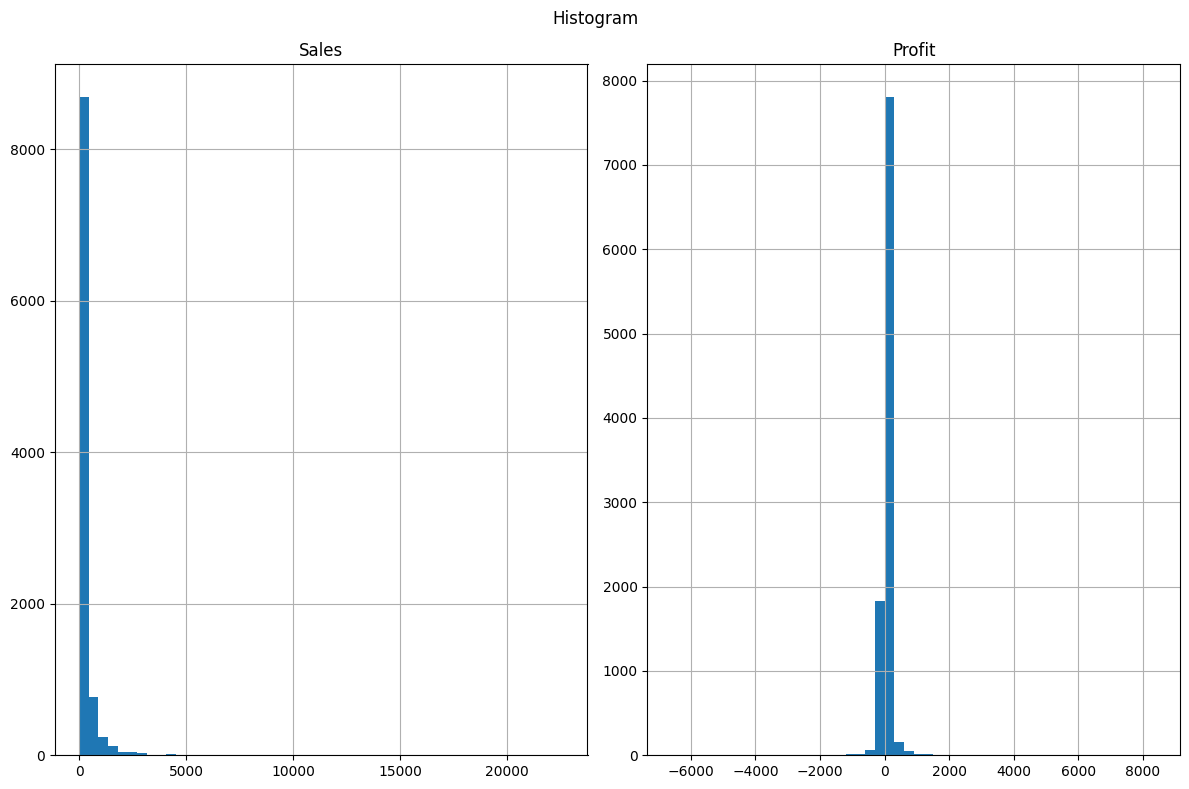

In [5]:
# Histogram untuk melihat penyebaran data (terutama untuk Profit)
df[['Sales', 'Profit']].hist(bins=50)
plt.suptitle('Histogram')
plt.tight_layout()
plt.show()

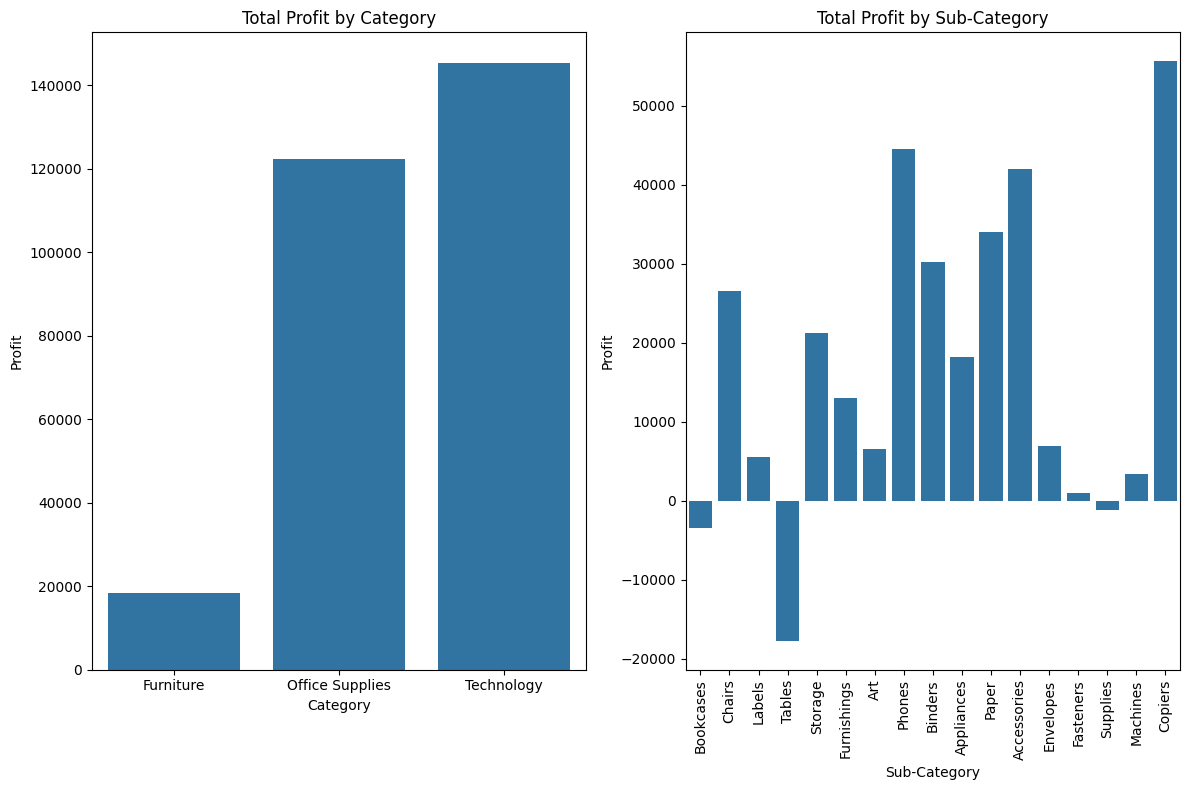

In [6]:
# Total profit per kategori dan sub kategori
# Profit per kategori tertinggi ada di kategori Technology
# Profit per sub kategori tertinggi ada di sub kategori Copiers
fig, axes = plt.subplots(1, 2)

sns.barplot(data=df, x='Category', y='Profit', estimator='sum', errorbar=None, ax=axes[0])
axes[0].set_title('Total Profit by Category')

sns.barplot(data=df, x='Sub-Category', y='Profit', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Total Profit by Sub-Category')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


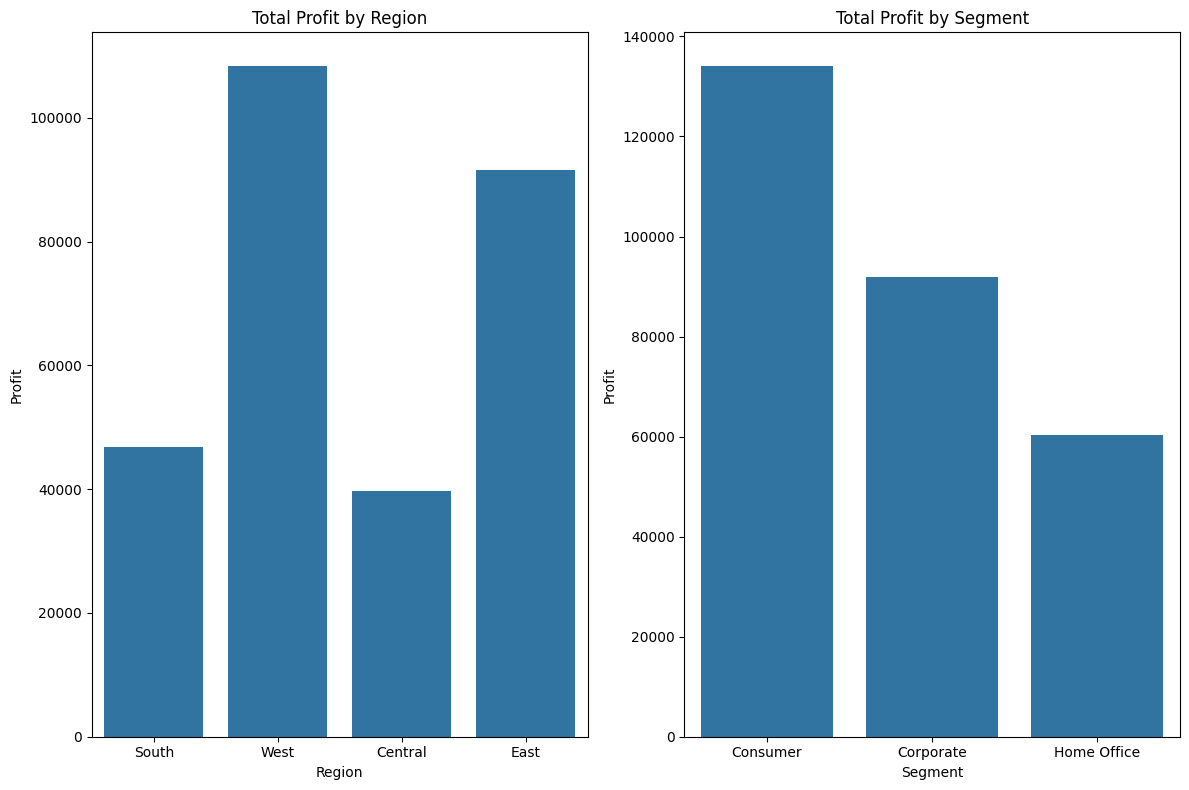

In [7]:
# Total profit per region dan segment
# Region dengan profit tertinggi ada di region West US
# Segment dengan profit tertinggi ada di segment Consumer
fig, axes = plt.subplots(1, 2)

sns.barplot(data=df, x='Region', y='Profit', estimator='sum', errorbar=None, ax=axes[0])
axes[0].set_title('Total Profit by Region')

sns.barplot(data=df, x='Segment', y='Profit', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Total Profit by Segment')

plt.tight_layout()
plt.show()


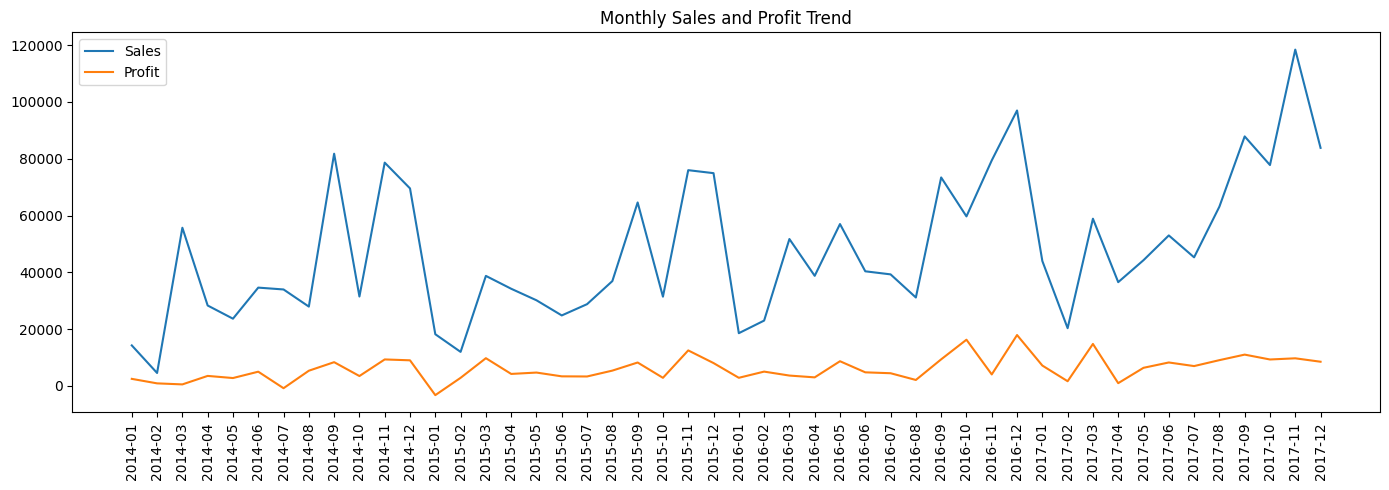

In [8]:
# Trend sales dan profit bulanan dari tahun 2014-2017
# Peningkatan sales dan profit secara signifikan di musim liburan pada bulan September-Januari
# Puncak trend biasanya di bulan Desember

# Konversi kolom ke datetime agar bisa melakukan operasi datetime, secara default tipe kolom object/string saat import csv
df['Order Date'] = pd.to_datetime(df['Order Date'])
# Kolom baru dari hasil konversi datetime ke format Year-Month, referensi https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_period.html
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

# Figure (14, 5) agar grafik proposional, tidak terlalu besar
plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['Sales'], label='Sales')
plt.plot(monthly['YearMonth'], monthly['Profit'], label='Profit')
plt.title('Monthly Sales and Profit Trend')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


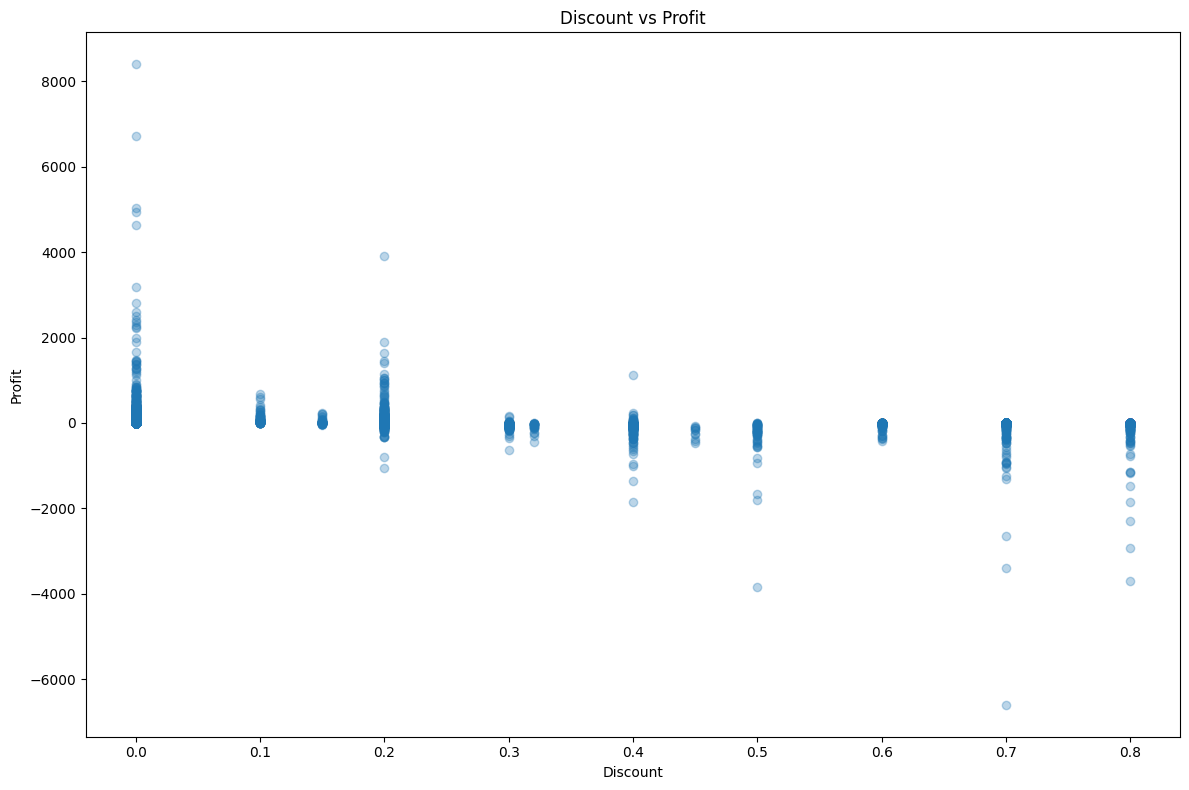

In [9]:
# Scatter plot untuk menggambarkan korelasi antara discount dan profit
# Hasil korelasi negatif yang tinggi, semakin tinggi diskon, semakin rendah profit yang didapatkan

plt.scatter(df['Discount'], df['Profit'], alpha=0.3)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


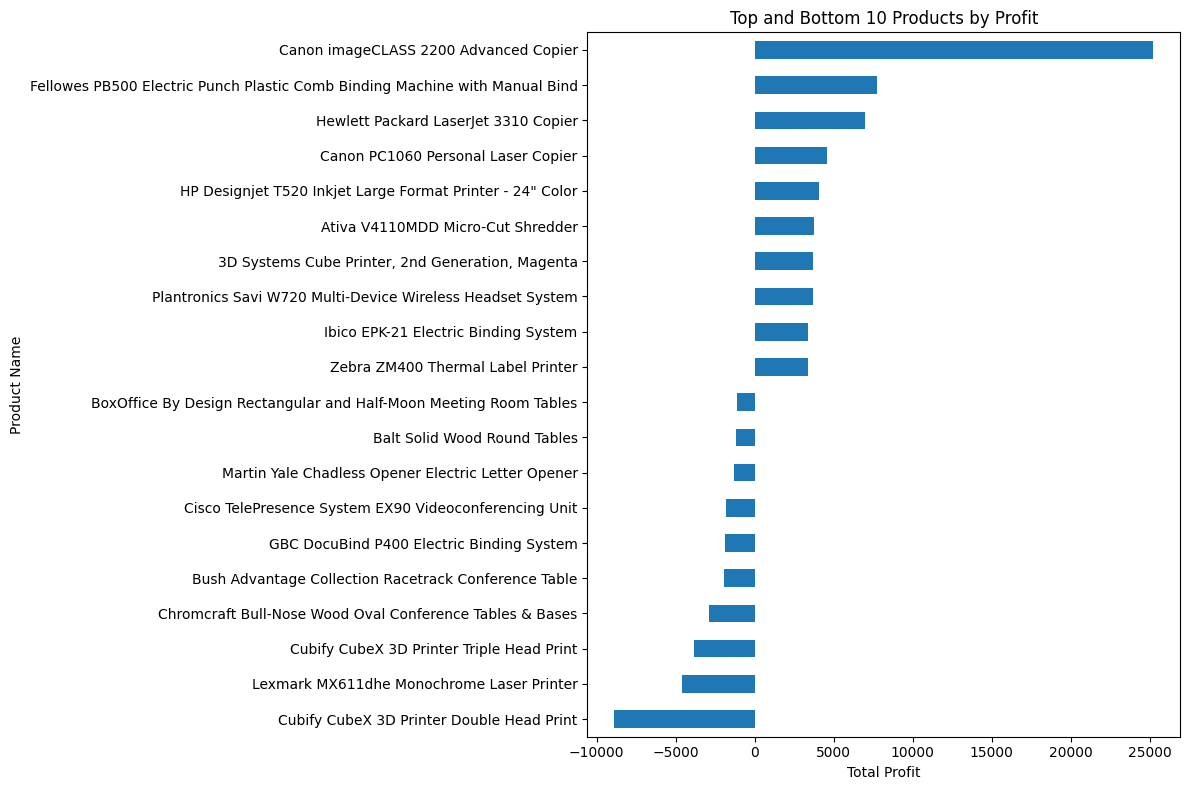

In [10]:
# Top 10 produk dengan profit tertinggi dan terendah
# Produk dengan profit tertinggi adalah Canon imageClass 2200
# Produk dengan profit terendah adalah Cubify CubeX 3D
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values()

top_bottom = pd.concat([product_profit.head(10), product_profit.tail(10)])
top_bottom.plot(kind='barh')

plt.title('Top and Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()


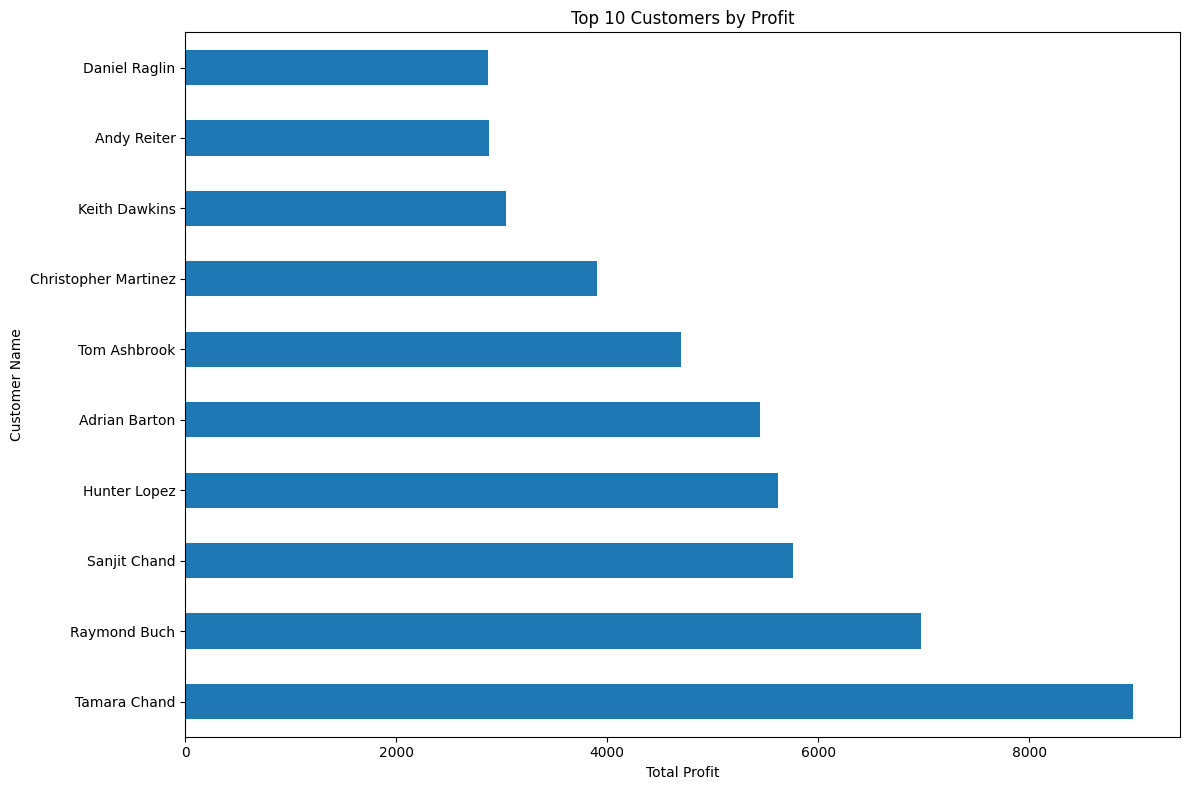

In [11]:
# Top 10 Customer Loyal dengan profit tertinggi
# Customer dengan profit tertinggi adalah Tamara Chand
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='barh')
plt.title('Top 10 Customers by Profit')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()


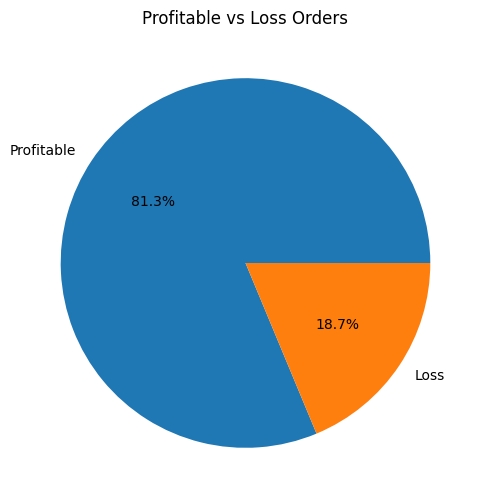

In [12]:
# Persentase sales profitable vs rugi dalam diagram pie
# 18.7% dari total order tidak profitable/rugi
labels = ['Profitable', 'Loss']
profitable_pct = (df['Profit'] >= 0).mean() * 100
loss_pct = (df['Profit'] < 0).mean() * 100
sizes = [profitable_pct, loss_pct]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Profitable vs Loss Orders')
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Menghapus kolom yang tidak relevan
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

In [13]:
# 1. Missing values
print(df.isnull().sum())
df = df.dropna()
print(df.shape)


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
YearMonth        0
dtype: int64
(9994, 22)


In [14]:
# 2. Menghapus duplikat
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [15]:
# 3. Menghapus kolom yang tidak relevan
# Kolom-kolom yang dihapus tidak bisa digunakan dalam prediksi Sales, terutama kolom high cardinality seperti 'Product Name' saat dilakukan one hot encoding akan menghasilkan banyak noise.
df = df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                       'Product ID', 'Product Name', 'Ship Date', 'Country', 'City',
                       'State', 'Postal Code', 'YearMonth'], errors='ignore')
df.head()

,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,Second Class,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,Standard Class,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [16]:
# 4. Deteksi outlier dan penanganan
# Karena Sales merupakan variabel target, nilai outlier dalam sales dapat mengakibatkan overfit saat training.
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Sales'] >= Q1 - 1.5 * IQR) & (df['Sales'] <= Q3 + 1.5 * IQR)]
print(df.shape)


(8827, 10)


In [17]:
# 5. Encode data kategorikal
# ML training akan menggunakan algoritma Linear Regression dan Random Forest, algoritma tersebut tidak memproses data string seperti kategori 'Furniture' sehingga harus dikonversi ke nilai 0/1 dalam kolom baru.
df = pd.get_dummies(df, columns=['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category'])
df.head()


,Order Date,Sales,Quantity,Discount,Profit,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Consumer,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2016-11-08,261.960,2,0.0,41.9136,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2016-06-12,14.620,2,0.0,6.8714,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,2015-10-11,22.368,2,0.2,2.5164,False,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
5,2014-06-09,48.860,7,0.0,14.1694,False,False,False,True,True,...,False,False,True,False,False,False,False,False,False,False
6,2014-06-09,7.280,4,0.0,1.9656,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


In [18]:
# 6. Normalisasi data numerik
scaler = MinMaxScaler()
df[['Quantity', 'Discount', 'Profit']] = scaler.fit_transform(df[['Quantity', 'Discount', 'Profit']])
df.head()


,Order Date,Sales,Quantity,Discount,Profit,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Consumer,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2016-11-08,261.960,0.076923,0.00,0.860108,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2016-06-12,14.620,0.076923,0.00,0.835468,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,2015-10-11,22.368,0.076923,0.25,0.832406,False,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
5,2014-06-09,48.860,0.461538,0.00,0.840600,False,False,False,True,True,...,False,False,True,False,False,False,False,False,False,False
6,2014-06-09,7.280,0.230769,0.00,0.832018,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


In [19]:
# 7. Binning kolom Discount (Low / Medium / High)
bins = [0, 0.2, 0.4, 1.0]
labels = ['Low', 'Medium', 'High']
df['Discount_Bin'] = pd.cut(df['Discount'], bins=bins, labels=labels, include_lowest=True)

print(df.shape)
print(df.dtypes)
df.head()

(8827, 37)
Order Date                  datetime64[ns]
Sales                              float64
Quantity                           float64
Discount                           float64
Profit                             float64
Ship Mode_First Class                 bool
Ship Mode_Same Day                    bool
Ship Mode_Second Class                bool
Ship Mode_Standard Class              bool
Segment_Consumer                      bool
Segment_Corporate                     bool
Segment_Home Office                   bool
Region_Central                        bool
Region_East                           bool
Region_South                          bool
Region_West                           bool
Category_Furniture                    bool
Category_Office Supplies              bool
Category_Technology                   bool
Sub-Category_Accessories              bool
Sub-Category_Appliances               bool
Sub-Category_Art                      bool
Sub-Category_Binders                  bool


,Order Date,Sales,Quantity,Discount,Profit,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Consumer,...,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Discount_Bin
0,2016-11-08,261.960,0.076923,0.00,0.860108,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,Low
2,2016-06-12,14.620,0.076923,0.00,0.835468,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,Low
4,2015-10-11,22.368,0.076923,0.25,0.832406,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,Medium
5,2014-06-09,48.860,0.461538,0.00,0.840600,False,False,False,True,True,...,False,True,False,False,False,False,False,False,False,Low
6,2014-06-09,7.280,0.230769,0.00,0.832018,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,Low
